Iteration 1: Cost 5031.3015, Weight 0.2174, Bias 1.3877
Iteration 101: Cost 185.5694, Weight 9.4592, Bias 60.3672
Iteration 201: Cost 100.3429, Weight 10.6849, Bias 68.1891
Iteration 301: Cost 98.8440, Weight 10.8474, Bias 69.2264
Iteration 401: Cost 98.8176, Weight 10.8690, Bias 69.3640


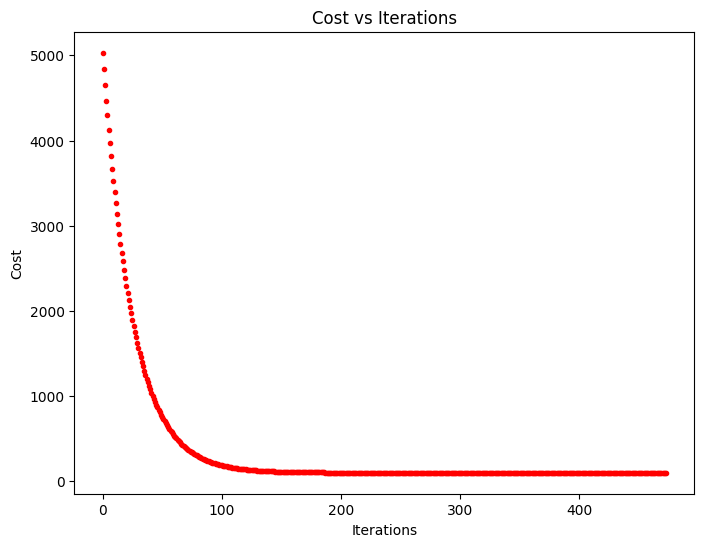


Estimated Weight: 10.8715
Estimated Bias: 69.3802


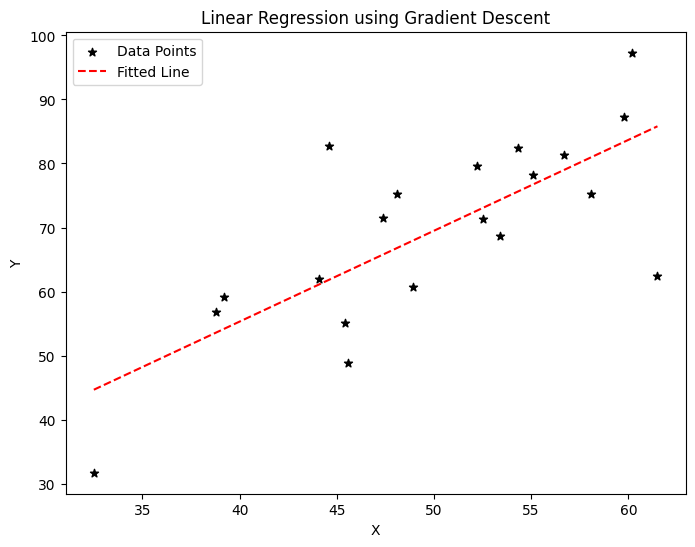

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def mean_squared_error(y_true, y_predicted):
    cost = np.sum((y_true - y_predicted) ** 2) / len(y_true)
    return cost

def gradient_descent(x, y, iterations=1000, learning_rate=0.01,
                     stopping_threshold=1e-6):

    current_weight = 0.0
    current_bias = 0.0

    n = float(len(x))
    costs = []
    previous_cost = None

    for i in range(iterations):

        y_predicted = current_weight * x + current_bias
        current_cost = mean_squared_error(y, y_predicted)

        if previous_cost is not None and abs(previous_cost - current_cost) <= stopping_threshold:
            break

        previous_cost = current_cost
        costs.append(current_cost)

        weight_derivative = -(2 / n) * sum(x * (y - y_predicted))
        bias_derivative = -(2 / n) * sum(y - y_predicted)

        current_weight = current_weight - learning_rate * weight_derivative
        current_bias = current_bias - learning_rate * bias_derivative

        if i % 100 == 0:
            print(f"Iteration {i + 1}: Cost {current_cost:.4f}, "
                  f"Weight {current_weight:.4f}, Bias {current_bias:.4f}")

    # Cost vs Iterations
    plt.figure(figsize=(8, 6))
    plt.plot(range(len(costs)), costs, 'r.')
    plt.title("Cost vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.show()

    return current_weight, current_bias


def main():

    X = np.array([
        32.5, 53.4, 61.5, 47.4, 59.8,
        55.1, 52.2, 39.2, 48.1, 52.5,
        45.4, 54.3, 44.1, 58.1, 56.7,
        48.9, 44.6, 60.2, 45.6, 38.8
    ])

    Y = np.array([
        31.7, 68.7, 62.5, 71.5, 87.2,
        78.2, 79.6, 59.1, 75.3, 71.3,
        55.1, 82.4, 62.0, 75.3, 81.4,
        60.7, 82.8, 97.3, 48.8, 56.8
    ])

    # Normalize X
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(
        X.reshape(-1, 1)
    ).flatten()

    # Apply Gradient Descent
    estimated_weight, estimated_bias = gradient_descent(
        X_normalized,
        Y,
        iterations=2000,
        learning_rate=0.01
    )

    print(f"\nEstimated Weight: {estimated_weight:.4f}")
    print(f"Estimated Bias: {estimated_bias:.4f}")

    # Predictions
    Y_pred = estimated_weight * X_normalized + estimated_bias

    # Plot fitted line
    plt.figure(figsize=(8, 6))
    plt.scatter(X, Y, color='black', label='Data Points', marker='*')

    # Sort X for a proper line
    sorted_indices = np.argsort(X)
    plt.plot(
        X[sorted_indices],
        Y_pred[sorted_indices],
        color='red',
        linestyle='--',
        label='Fitted Line'
    )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Linear Regression using Gradient Descent")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()